In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
data_orginal = pd.read_excel('Dry_Bean_Dataset.xlsx')
data = data_orginal.copy()
data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
data.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

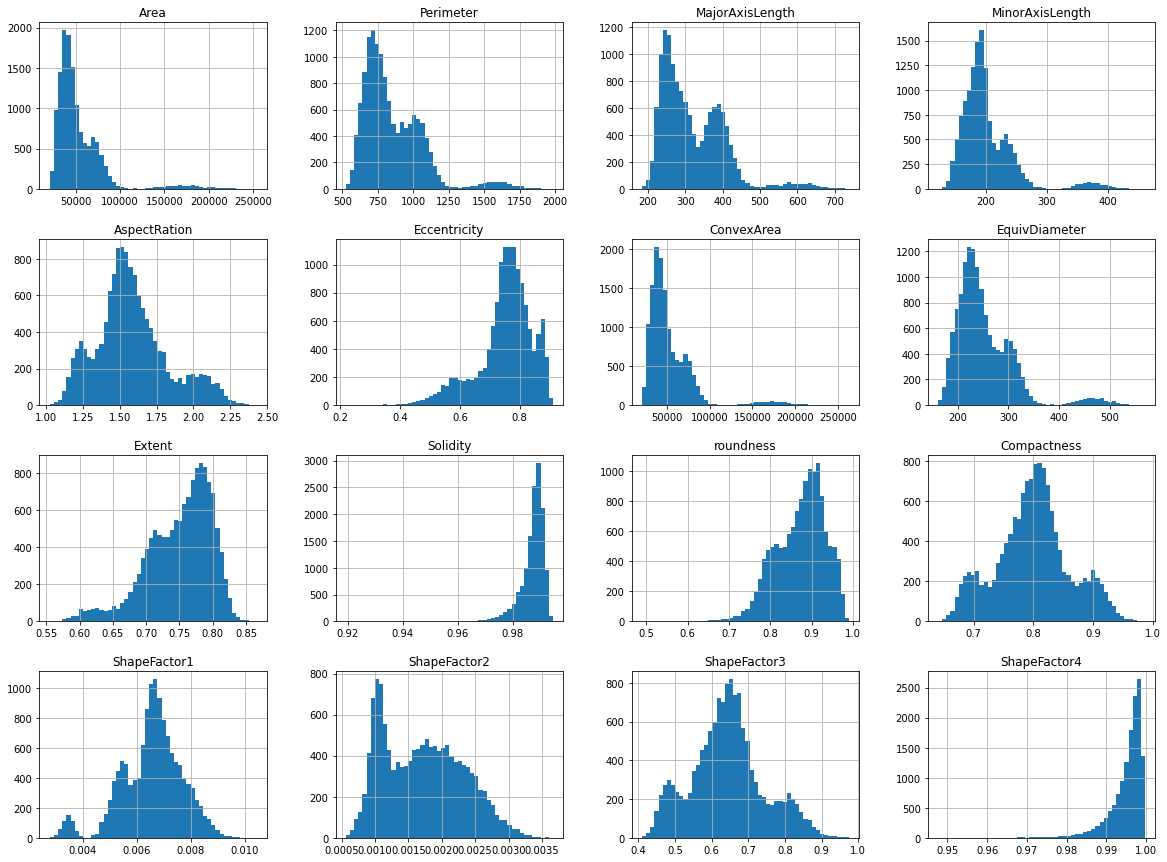

In [5]:
data.hist(bins=50, figsize=(20,15))
plt.show()

In [6]:
X_train, X_test = train_test_split(data, test_size=0.3, random_state=42)

ordinal_encoder = OrdinalEncoder()

beam_y_train = ordinal_encoder.fit_transform(X_train[['Class']]).flatten() 
beam_y_test = ordinal_encoder.fit_transform(X_test[['Class']]).flatten()

In [7]:
X_train['Class'] = beam_y_train
corr_matrix = X_train.corr()
corr_matrix['Class'].sort_values()

Perimeter         -0.507896
EquivDiameter     -0.481314
ConvexArea        -0.477595
Area              -0.475368
MinorAxisLength   -0.459266
MajorAxisLength   -0.455041
Eccentricity      -0.201516
AspectRation      -0.116985
Extent            -0.031780
Compactness        0.156912
ShapeFactor4       0.159744
ShapeFactor3       0.168441
Solidity           0.316358
ShapeFactor2       0.335689
roundness          0.385670
ShapeFactor1       0.392970
Class              1.000000
Name: Class, dtype: float64

In [8]:
standard_scaler = StandardScaler()

beam_X_train = X_train.drop('Class', axis=1)
beam_X_train = standard_scaler.fit_transform(beam_X_train)
beam_X_test = X_test.drop('Class', axis=1)
beam_X_test = standard_scaler.fit_transform(beam_X_test)

In [9]:
sgd_clf = SGDClassifier(random_state=42)
forest_clf = RandomForestClassifier(random_state=42)

In [10]:
print(cross_val_score(sgd_clf, beam_X_train, beam_y_train, cv=4, scoring='accuracy').mean())
print(cross_val_score(forest_clf, beam_X_train, beam_y_train, cv=4, scoring='accuracy').mean())

0.9153979640810206
0.9218009846352191


In [11]:
beam_y_pred = cross_val_predict(sgd_clf, beam_X_train, beam_y_train, cv=4)
precision = precision_score(beam_y_train, beam_y_pred, average=None).mean()
f1 = f1_score(beam_y_train, beam_y_pred, average=None).mean()
recall = recall_score(beam_y_train, beam_y_pred, average=None).mean()

beam_y_pred_forest = cross_val_predict(forest_clf, beam_X_train, beam_y_train, cv=4)
precision_forest = precision_score(beam_y_train, beam_y_pred_forest, average=None).mean()
f1_forest = f1_score(beam_y_train, beam_y_pred_forest, average=None).mean()
recall_forest = recall_score(beam_y_train, beam_y_pred_forest, average=None).mean()

print(f'FOREST: \nPrecyzja: {precision_forest} \nCzułość: {recall_forest} \nF1: {f1_forest}')
print(f'SGD: \nPrecyzja: {precision} \nCzułość: {recall} \nF1: {f1}')

print('SGD: \n', confusion_matrix(beam_y_train, beam_y_pred))
print('Forest: \n', confusion_matrix(beam_y_train, beam_y_pred_forest))

FOREST: 
Precyzja: 0.935052288857323 
Czułość: 0.9308508579150307 
F1: 0.9328506200667347
SGD: 
Precyzja: 0.9301567385702239 
Czułość: 0.9267560325086338 
F1: 0.9283131802086102
SGD: 
 [[ 836    0   47    0    6    6   32]
 [   2  358    1    0    0    0    0]
 [  30    0 1074    0   24    1   22]
 [   3    0    0 2259    3   51  187]
 [   3    0   26   13 1267    0   31]
 [  13    0    0   18    0 1322   55]
 [   5    0    3  162   33   29 1605]]
Forest: 
 [[ 833    1   52    0    8    9   24]
 [   2  359    0    0    0    0    0]
 [  34    0 1083    0   24    1    9]
 [   0    0    0 2331    5   34  133]
 [   5    0   22   13 1263    0   37]
 [   4    0    1   30    0 1341   32]
 [   9    0    4  196   29   27 1572]]


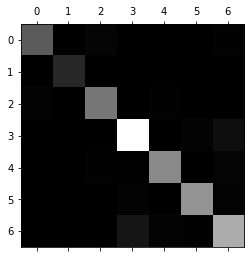

In [12]:
conf = confusion_matrix(beam_y_train, beam_y_pred_forest)
plt.matshow(conf, cmap=plt.cm.gray)
plt.show()

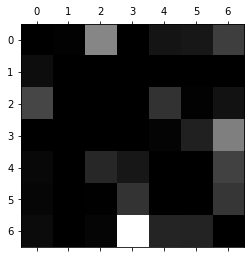

In [13]:
row_sums = conf.sum(axis=1, keepdims=True)
norm_conf_mx = conf / row_sums
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

In [14]:
sgd_clf.fit(beam_X_train, beam_y_train)
forest_clf.fit(beam_X_train, beam_y_train)

RandomForestClassifier(random_state=42)

In [15]:
decision = sgd_clf.decision_function([beam_X_train[5]])
forest = forest_clf.predict_proba([beam_X_train[5]])

print(beam_y_train[5])
print('SGD: ', decision)
print('Forest: ', forest)

6.0
SGD:  [[  -3.49275502 -179.26122184   -8.75181879    0.23387994   -7.27089367
    -2.94560595    0.64465139]]
Forest:  [[0.   0.   0.   0.19 0.   0.   0.81]]


In [16]:
test_prediction = forest_clf.predict(beam_X_test)
accuracy_score(beam_y_test,test_prediction)

0.9236043095004897

In [17]:
param_grid =[
    {'n_estimators': [150, 200], 'max_features': [6, 8, 12], 'max_depth': [8, 10, 14],
     'criterion': ['entropy'],'bootstrap': [False]}
]

grid_search = GridSearchCV(forest_clf, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(beam_X_train, beam_y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid=[{'bootstrap': [False], 'criterion': ['entropy'],
                          'max_depth': [3, 5, 8], 'max_features': [2, 4, 6],
                          'n_estimators': [150, 200]}],
             return_train_score=True, scoring='accuracy')

In [19]:
grid_search.best_estimator_

RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=8,
                       max_features=6, n_estimators=150, random_state=42)

In [20]:
final_model = grid_search
test_prediction = final_model.predict(beam_X_test)
accuracy_score(beam_y_test,test_prediction)

0.9204211557296768

In [21]:
joblib.dump(final_model,'Beam_Classifier.pkl')

['Beam_Classifier.pkl']